# 04 — Commercial Analysis

This notebook analyses lead and sales activity and measures commercial pressure for each course-location combination.

The analysis examines:

1. the distribution of leads, sales, and conversion across courses, locations, modalities, and professional areas;
2. recent and historical commercial volume;
3. lead-to-sale conversion;
4. the regularity of commercial activity;
5. recent changes in lead and sales volumes;
6. the relative commercial pressure of each course-location combination.

The final output is a commercial pressure score that contributes to the overall hiring-priority model.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## Project configuration

The notebook reads the validated commercial and course-reference datasets from `data/processed/`.

The commercial features and pressure scores are exported to `data/scores/` for integration with the workforce and training-activity dimensions.

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

SCORES_DATA_DIR = Path("../data/scores")

## Data import

Three processed datasets are used:

- `leads.csv`: weekly lead volume by course, location, and modality;
- `sales.csv`: weekly sales volume by course, location, and modality;
- `info_actions.csv`: course names, professional areas, reference durations, and catalogue status.

Date columns are parsed during import to support weekly aggregation, period comparisons, trend analysis, and commercial feature construction.

In [3]:
leads_df = pd.read_csv(PROCESSED_DATA_DIR / "leads.csv", sep=",", encoding="utf-8", parse_dates=["date"])

sales_df = pd.read_csv(PROCESSED_DATA_DIR / "sales.csv", sep=",", encoding="utf-8", parse_dates=["date"])

info_actions_df = pd.read_csv(PROCESSED_DATA_DIR / "info_actions.csv", sep=",", encoding="utf-8")

## Analytical commercial base

Lead and sales records are combined using course, location, modality, and date as the analytical key.

An outer merge preserves weeks appearing in only one of the two commercial datasets. Missing lead or sales volumes are filled with zero.

Course-reference information is then added, and inactive catalogue courses are excluded. The resulting dataset represents the complete observed commercial activity for active courses.

In [4]:
merge_keys = ["course_id", "local", "modality", "date"]

active_courses_df = info_actions_df.loc[info_actions_df["active"]].copy()

commercial_analysis = (
    leads_df
    .merge(
        sales_df,
        how="outer",
        on=["course_id", "local", "modality", "date"],
        validate="one_to_one"
    )
    .fillna({
        "total_leads": 0,
        "total_sales": 0
    })
    .astype({
        "total_leads": "int64",
        "total_sales": "int64"
    })
    .merge(
        active_courses_df,
        how="inner",
        on="course_id",
        validate="many_to_one"
    )
)

commercial_analysis = commercial_analysis[["course_id", "course_name", "course_area", "local", "modality", "date", "total_sales", "total_leads"]]

commercial_analysis

,course_id,course_name,course_area,local,modality,date,total_sales,total_leads
0,CYB,Cibersegurança Básica,Informática,Centro 1,Hybrid,2023-03-20,11,44
1,CYB,Cibersegurança Básica,Informática,Centro 1,Hybrid,2023-03-27,21,79
2,CYB,Cibersegurança Básica,Informática,Centro 1,Hybrid,2023-04-17,5,19
3,CYB,Cibersegurança Básica,Informática,Centro 1,Hybrid,2023-04-24,9,33
4,CYB,Cibersegurança Básica,Informática,Centro 1,Hybrid,2023-05-08,6,22
...,...,...,...,...,...,...,...,...
23981,VND,Vendas e Negociação,Comercial,Centro 5,Online,2026-10-26,21,67
23982,VND,Vendas e Negociação,Comercial,Centro 5,Online,2026-11-02,20,66
23983,VND,Vendas e Negociação,Comercial,Centro 5,Online,2026-11-09,24,77
23984,VND,Vendas e Negociação,Comercial,Centro 5,Online,2026-11-16,12,39


## Commercial activity overview

The commercial dataset contains 794,850 leads and 244,687 sales across:

- 24 active courses;
- 5 training centres;
- 3 delivery modalities;
- a time span from 2023 to 2026.

The overall lead-to-sale conversion rate is approximately 30.8%.

This overview describes the complete commercial dataset. A specific analytical cutoff is defined later for the commercial-pressure model.

## Distribution of commercial activity

A reusable summary function calculates:

- total leads;
- total sales;
- percentage of overall leads;
- percentage of overall sales;
- lead-to-sale conversion rate.

Commercial activity is then examined by course, location, modality, professional area, and combinations of these variables.

These summaries identify how commercial demand and completed sales are distributed before recent and historical features are calculated.

In [5]:
def summarize_commercial(df, group_columns):
    summary = (
        df
        .groupby(group_columns, as_index=False)
        .agg(
            leads_count=("total_leads", "sum"),
            sales_count=("total_sales", "sum")
        )
        .assign(
            pct_leads=lambda data:
                data["leads_count"]
                .div(data["leads_count"].sum())
                .mul(100)
                .round(1),

            pct_sales=lambda data:
                data["sales_count"]
                .div(data["sales_count"].sum())
                .mul(100)
                .round(1),

            conversion_rate=lambda data:
                data["sales_count"]
                .div(data["leads_count"])
                .mul(100)
                .fillna(0)
                .round(1)
        )
        .sort_values(
            by="leads_count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return summary

In [6]:
commercial_course_count = summarize_commercial(
    commercial_analysis,
    ["course_id", "course_name"]
)

commercial_course_count

,course_id,course_name,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,CYB,Cibersegurança Básica,66543,18683,8.4,7.6,28.1
1,PBI,Power BI e Visualização de Dados,61525,19047,7.7,7.8,31.0
2,EXC,Excel Aplicado à Gestão,44103,14732,5.5,6.0,33.4
3,PYT,Introdução à Programação em Python,43917,11974,5.5,4.9,27.3
4,SST,Saúde e Segurança no Trabalho,38797,12799,4.9,5.2,33.0
5,SEG,Segurança no Trabalho,37063,12505,4.7,5.1,33.7
6,GER,Geriatria e Apoio ao Idoso,35497,11040,4.5,4.5,31.1
7,LID,Liderança e Comunicação,34561,9980,4.3,4.1,28.9
8,MNT,Manutenção Industrial Básica,33758,9849,4.2,4.0,29.2
9,LOG,Logística e Gestão de Armazém,33364,11027,4.2,4.5,33.1


In [7]:
commercial_local_count = summarize_commercial(
    commercial_analysis,
    ["local"]
)

commercial_local_count

,local,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,Centro 2,167758,53151,21.1,21.7,31.7
1,Centro 1,159519,48598,20.1,19.9,30.5
2,Centro 3,157033,46426,19.8,19.0,29.6
3,Centro 4,155610,49908,19.6,20.4,32.1
4,Centro 5,154930,46604,19.5,19.0,30.1


In [8]:
commercial_modality_count = summarize_commercial(
    commercial_analysis,
    ["modality"]
)

commercial_modality_count

,modality,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,In-person,331313,103344,41.7,42.2,31.2
1,Hybrid,262264,80655,33.0,33.0,30.8
2,Online,201273,60688,25.3,24.8,30.2


In [9]:
commercial_course_area_count = summarize_commercial(
    commercial_analysis,
    ["course_area"]
)

commercial_course_area_count

,course_area,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,Informática,216088,64436,27.2,26.3,29.8
1,Segurança,121720,39492,15.3,16.1,32.4
2,Gestão,92474,25982,11.6,10.6,28.1
3,Saúde,59611,18704,7.5,7.6,31.4
4,Saúde e Segurança,51089,16600,6.4,6.8,32.5
5,Alimentar,50410,17230,6.3,7.0,34.2
6,Turismo,44704,14129,5.6,5.8,31.6
7,Manutenção,33758,9849,4.2,4.0,29.2
8,Logística,33364,11027,4.2,4.5,33.1
9,Comercial,33008,10108,4.2,4.1,30.6


In [10]:
commercial_course_local_count = summarize_commercial(
    commercial_analysis,
    ["course_id", "course_name", "local"]
)

commercial_course_local_count

,course_id,course_name,local,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,CYB,Cibersegurança Básica,Centro 4,17325,5078,2.2,2.1,29.3
1,PBI,Power BI e Visualização de Dados,Centro 4,16580,5382,2.1,2.2,32.5
2,PBI,Power BI e Visualização de Dados,Centro 2,15455,4915,1.9,2.0,31.8
3,CYB,Cibersegurança Básica,Centro 2,14602,4227,1.8,1.7,28.9
4,PYT,Introdução à Programação em Python,Centro 2,12791,3615,1.6,1.5,28.3
...,...,...,...,...,...,...,...,...
115,SOC,Socorrismo Básico,Centro 1,2924,853,0.4,0.3,29.2
116,SOC,Socorrismo Básico,Centro 2,2811,874,0.4,0.4,31.1
117,HOT,Housekeeping e Operações Hoteleiras,Centro 4,2651,891,0.3,0.4,33.6
118,GES,Gestão de Equipas,Centro 3,2646,698,0.3,0.3,26.4


In [11]:
commercial_course_modality_count = summarize_commercial(
    commercial_analysis,
    ["course_id", "course_name", "modality"]
)

commercial_course_modality_count

,course_id,course_name,modality,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,MNT,Manutenção Industrial Básica,In-person,33758,9849,4.2,4.0,29.2
1,PBI,Power BI e Visualização de Dados,Online,31037,9645,3.9,3.9,31.1
2,CYB,Cibersegurança Básica,Online,30660,8617,3.9,3.5,28.1
3,CYB,Cibersegurança Básica,Hybrid,23999,6745,3.0,2.8,28.1
4,GER,Geriatria e Apoio ao Idoso,In-person,22976,7150,2.9,2.9,31.1
5,EXC,Excel Aplicado à Gestão,Online,21532,7237,2.7,3.0,33.6
6,PRI,Primeiros Socorros,In-person,20696,7107,2.6,2.9,34.3
7,LOG,Logística e Gestão de Armazém,In-person,20692,6833,2.6,2.8,33.0
8,PBI,Power BI e Visualização de Dados,Hybrid,20423,6299,2.6,2.6,30.8
9,PYT,Introdução à Programação em Python,Online,20152,5539,2.5,2.3,27.5


In [12]:
commercial_local_modality_count = summarize_commercial(
    commercial_analysis,
    ["local", "modality"]
)

commercial_local_modality_count

,local,modality,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,Centro 5,In-person,70567,21463,8.9,8.8,30.4
1,Centro 3,In-person,69985,20973,8.8,8.6,30.0
2,Centro 1,In-person,68101,21090,8.6,8.6,31.0
3,Centro 2,In-person,63710,20601,8.0,8.4,32.3
4,Centro 4,In-person,58950,19217,7.4,7.9,32.6
5,Centro 2,Hybrid,56791,17910,7.1,7.3,31.5
6,Centro 3,Hybrid,53407,15788,6.7,6.5,29.6
7,Centro 1,Hybrid,53360,16248,6.7,6.6,30.4
8,Centro 4,Hybrid,51241,16391,6.4,6.7,32.0
9,Centro 5,Hybrid,47465,14318,6.0,5.9,30.2


## Commercial activity visualisation

A reusable plotting function is created to compare lead volume, sales volume, and conversion rates across categorical variables.

The overview visualisations present:

- courses with the greatest lead, sales, and conversion results;
- commercial activity by professional area;
- commercial activity across training centres;
- commercial activity by delivery modality.

Informática generates the greatest lead and sales volumes. Centre 2 records the largest total volume of leads and sales, while Centre 4 has the highest overall conversion rate. In-person training generates the greatest commercial volume and the highest conversion rate among the three modalities.

In [13]:
def plot_commercial_overview(charts, title, ylabel, nrows=2, ncols=2, figsize=(13, 9)):

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor="#E9ECEF", squeeze=False)

    fig.suptitle(title, fontsize=16, fontweight="bold")

    metric_columns = {
        "leads": {
            "value": "leads_count",
            "percentage": "pct_leads"
        },
        "sales": {
            "value": "sales_count",
            "percentage": "pct_sales"
        },
        "conversion": {
            "value": "conversion_rate",
            "percentage": None
        },
        "score": {
            "value": "commercial_count",
            "percentage": "pct_commercial"
        }
    }

    for ax, chart in zip(axes.flat, charts.values()):

        plot_df = chart["df"].copy()

        metric = chart["metric"]

        value_column = metric_columns[metric]["value"]
        percentage_column = metric_columns[metric]["percentage"]

        if chart.get("sort", True):
            plot_df = plot_df.sort_values(by=value_column, ascending=False)

        if "top_n" in chart:
            plot_df = plot_df.head(
                chart["top_n"]
            )

        if "label_columns" in chart:
            categories = (
                plot_df[chart["label_columns"]]
                .astype(str)
                .agg(" | ".join, axis=1)
            )

        else:
            categories = (
                plot_df[chart["label_column"]]
                .astype(str)
            )

        values = plot_df[value_column]

        bars = ax.bar(
            categories,
            values
        )

        if metric == "conversion":

            labels = [
                f"{value:.1f}%"
                for value in values
            ]

        elif metric == "score":

            percentages = plot_df[percentage_column]

            labels = [
                f"{value:.0f}\n({percentage:.1f}%)"
                for value, percentage
                in zip(values, percentages)
            ]

        else:

            percentages = plot_df[percentage_column]

            labels = [
                f"{value / 1000:.1f}K\n({percentage:.1f}%)"
                for value, percentage
                in zip(values, percentages)
            ]

        ax.bar_label(
            bars,
            labels=labels,
            padding=4,
            fontsize=8
        )

        ax.set_title(
            chart["title"],
            loc="left",
            fontweight="bold",
            pad=25
        )

        ax.text(
            0,
            1.02,
            chart["description"],
            transform=ax.transAxes,
            fontsize=9,
            color="#6B7280"
        )

        ax.set_facecolor("#FFFFFF")
        ax.set_ylabel(ylabel)

        maximum_value = values.max()

        ax.set_ylim(
            0,
            maximum_value * 1.25
            if maximum_value > 0
            else 1
        )

        ax.tick_params(
            axis="x",
            rotation=45
        )

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    for ax in axes.flat[len(charts):]:
        ax.set_visible(False)

    plt.tight_layout(
        rect=[0, 0, 1, 0.95],
        h_pad=3
    )

    plt.show()

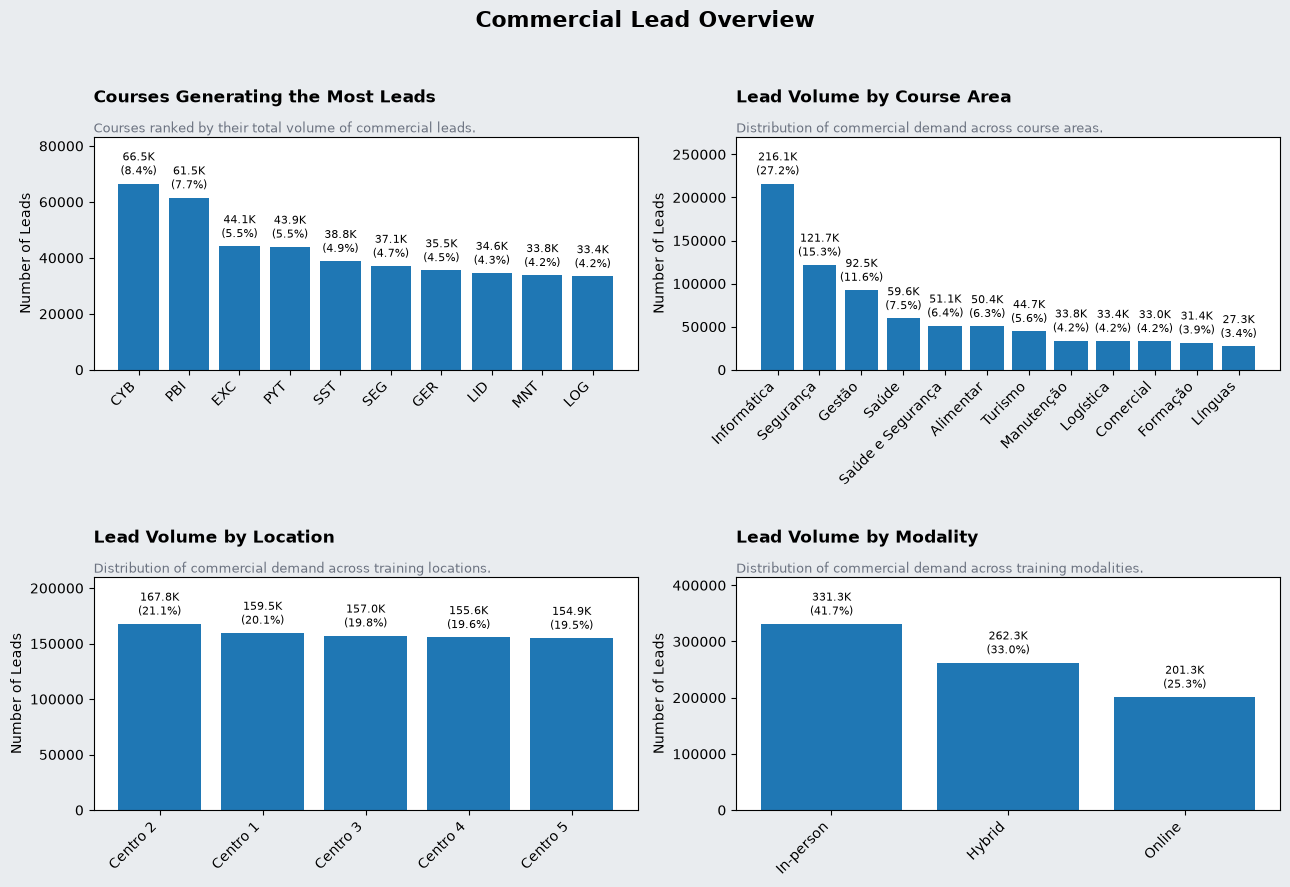

In [14]:
commercial_leads_overview_charts = {
    "course": {
        "df": commercial_course_count,
        "label_column": "course_id",
        "metric": "leads",
        "title": "Courses Generating the Most Leads",
        "description": (
            "Courses ranked by their total volume of commercial leads."
        ),
        "top_n": 10
    },

    "course_area": {
        "df": commercial_course_area_count,
        "label_column": "course_area",
        "metric": "leads",
        "title": "Lead Volume by Course Area",
        "description": (
            "Distribution of commercial demand across course areas."
        )
    },

    "local": {
        "df": commercial_local_count,
        "label_column": "local",
        "metric": "leads",
        "title": "Lead Volume by Location",
        "description": (
            "Distribution of commercial demand across training locations."
        )
    },

    "modality": {
        "df": commercial_modality_count,
        "label_column": "modality",
        "metric": "leads",
        "title": "Lead Volume by Modality",
        "description": (
            "Distribution of commercial demand across training modalities."
        )
    }
}

plot_commercial_overview(
    charts=commercial_leads_overview_charts,
    title="Commercial Lead Overview",
    ylabel="Number of Leads",
    nrows=2,
    ncols=2,
    figsize=(13, 9)
)

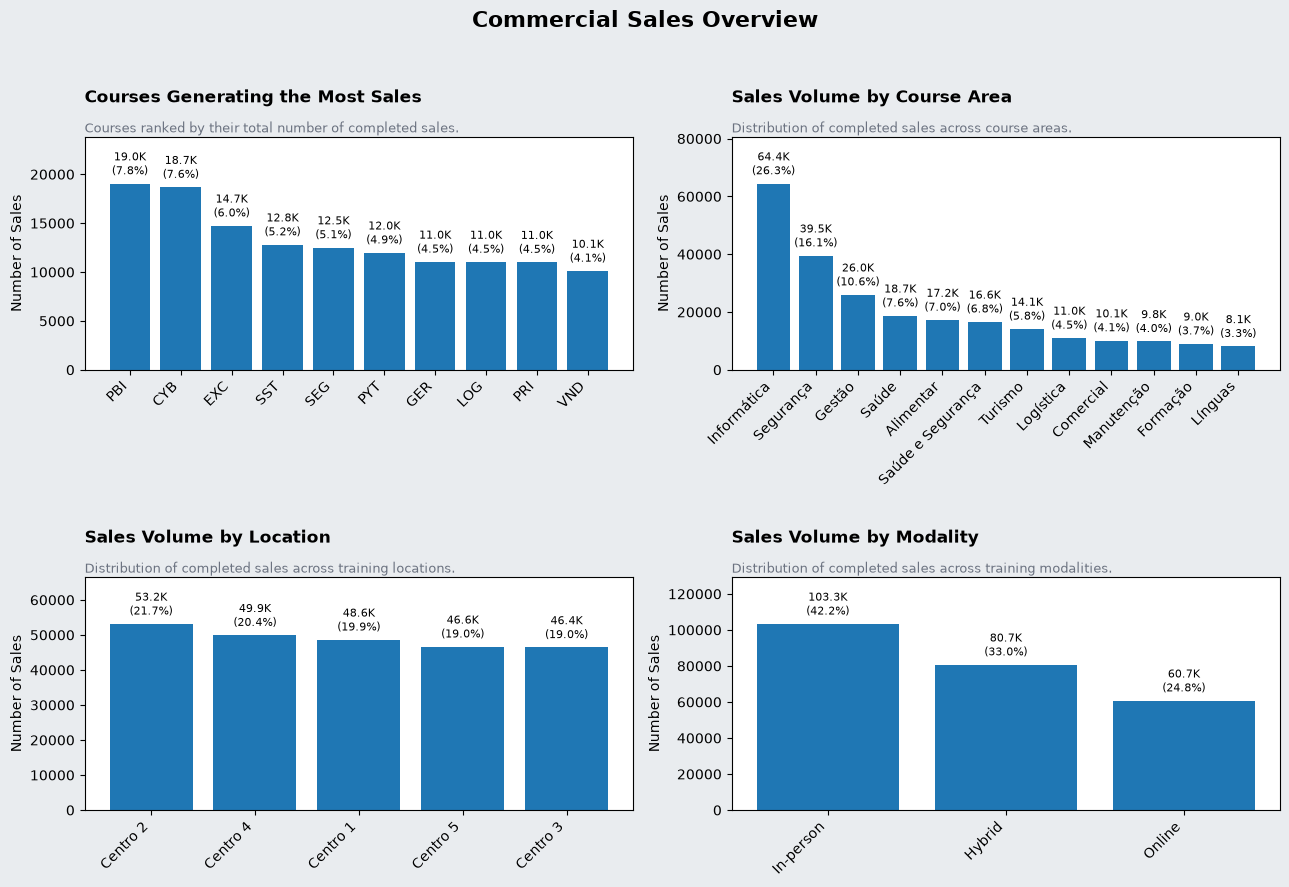

In [15]:
commercial_sales_overview_charts = {
    "course": {
        "df": commercial_course_count,
        "label_column": "course_id",
        "metric": "sales",
        "title": "Courses Generating the Most Sales",
        "description": (
            "Courses ranked by their total number of completed sales."
        ),
        "top_n": 10
    },

    "course_area": {
        "df": commercial_course_area_count,
        "label_column": "course_area",
        "metric": "sales",
        "title": "Sales Volume by Course Area",
        "description": (
            "Distribution of completed sales across course areas."
        )
    },

    "local": {
        "df": commercial_local_count,
        "label_column": "local",
        "metric": "sales",
        "title": "Sales Volume by Location",
        "description": (
            "Distribution of completed sales across training locations."
        )
    },

    "modality": {
        "df": commercial_modality_count,
        "label_column": "modality",
        "metric": "sales",
        "title": "Sales Volume by Modality",
        "description": (
            "Distribution of completed sales across training modalities."
        )
    }
}

plot_commercial_overview(
    charts=commercial_sales_overview_charts,
    title="Commercial Sales Overview",
    ylabel="Number of Sales",
    nrows=2,
    ncols=2,
    figsize=(13, 9)
)

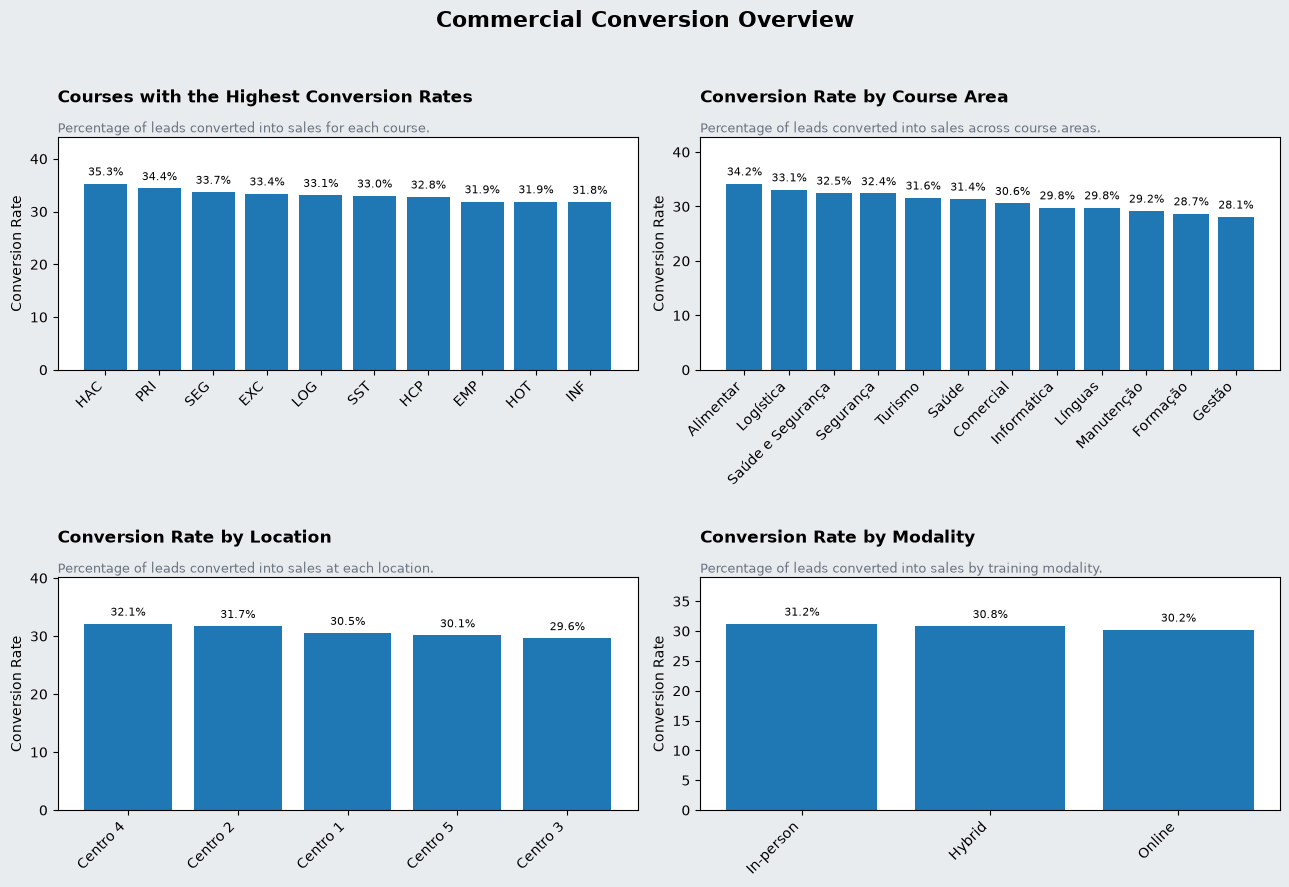

In [16]:
commercial_conversion_overview_charts = {
    "course": {
        "df": commercial_course_count,
        "label_column": "course_id",
        "metric": "conversion",
        "title": "Courses with the Highest Conversion Rates",
        "description": (
            "Percentage of leads converted into sales for each course."
        ),
        "top_n": 10
    },

    "course_area": {
        "df": commercial_course_area_count,
        "label_column": "course_area",
        "metric": "conversion",
        "title": "Conversion Rate by Course Area",
        "description": (
            "Percentage of leads converted into sales across course areas."
        )
    },

    "local": {
        "df": commercial_local_count,
        "label_column": "local",
        "metric": "conversion",
        "title": "Conversion Rate by Location",
        "description": (
            "Percentage of leads converted into sales at each location."
        )
    },

    "modality": {
        "df": commercial_modality_count,
        "label_column": "modality",
        "metric": "conversion",
        "title": "Conversion Rate by Modality",
        "description": (
            "Percentage of leads converted into sales by training modality."
        )
    }
}

plot_commercial_overview(
    charts=commercial_conversion_overview_charts,
    title="Commercial Conversion Overview",
    ylabel="Conversion Rate",
    nrows=2,
    ncols=2,
    figsize=(13, 9)
)

## Commercial feature scope

Commercial features are calculated at the course-location level. Modalities are aggregated because the final hiring-priority model evaluates each course within each training centre.

The analysis date is 29 July 2026. The week beginning 20 July 2026 is defined as the latest completed reference week.

Two periods are compared:

- **Last 13 weeks:** 27 April 2026 to 20 July 2026;
- **Historical:** 2 January 2023 to 20 April 2026.

Only commercial activity recorded on or before the reference week is retained for feature construction.

In [17]:
group_columns = [
    "course_id",
    "course_name",
    "course_area",
    "local"
]


commercial_weekly_raw_df = (
    commercial_analysis
    .loc[
        :,
        group_columns + [
            "date",
            "total_leads",
            "total_sales"
        ]
    ]
    .assign(
        date=lambda df:
            pd.to_datetime(df["date"])
    )
    .groupby(
        group_columns + ["date"],
        as_index=False
    )
    .agg(
        total_leads=(
            "total_leads",
            "sum"
        ),

        total_sales=(
            "total_sales",
            "sum"
        )
    )
)

commercial_features_base = commercial_weekly_raw_df.copy()

In [18]:
recent_weeks = 13


ANALYSIS_DATE = pd.Timestamp("2026-07-29")

current_week_start = (
    ANALYSIS_DATE
    - pd.to_timedelta(ANALYSIS_DATE.weekday(), unit="D")
)

reference_week = current_week_start - pd.Timedelta(weeks=1)

last_13w_start_week = (
    reference_week
    - pd.Timedelta(weeks=recent_weeks - 1)
)

reference_date = reference_week

In [19]:
commercial_features_base = (
    commercial_features_base
    .loc[
        commercial_features_base["date"].le(reference_week)
    ]
    .copy()
)

commercial_features_base["period"] = "historical"


commercial_features_base.loc[
    commercial_features_base["date"]
    .ge(last_13w_start_week),
    "period"
] = "last_13w"

In [20]:
course_local_combinations = commercial_features_base[group_columns].drop_duplicates().reset_index(drop=True)

print(
    f"Last 13 weeks: "
    f"{last_13w_start_week.date()} - "
    f"{reference_week.date()}"
)


print(
    f"Historical: "
    f"{commercial_features_base['date'].min().date()} - "
    f"{(
        last_13w_start_week
        - pd.Timedelta(weeks=1)
    ).date()}"
)

Last 13 weeks: 2026-04-27 - 2026-07-20
Historical: 2023-01-02 - 2026-04-20


## Complete weekly time series

A complete sequence of weeks is generated for every course-location combination, including weeks without leads or sales.

Missing weekly observations are filled with zero commercial activity. This is essential for measuring:

- true weekly averages;
- periods without leads or sales;
- commercial regularity;
- weekly changes in activity.

Without these zero-activity weeks, the model would overestimate the frequency and continuity of commercial demand.

In [21]:
all_weeks_df = pd.DataFrame({
    "date": pd.date_range(
        start=commercial_features_base["date"].min(),
        end=reference_week,
        freq="W-MON"
    )
})

In [22]:
commercial_weekly_df = (
    course_local_combinations
    .merge(
        all_weeks_df,
        how="cross"
    )
    .merge(
        commercial_weekly_raw_df,
        on=group_columns + ["date"],
        how="left",
        validate="one_to_one"
    )
    .fillna({
        "total_leads": 0,
        "total_sales": 0
    })
)

commercial_weekly_df[
    [
        "total_leads",
        "total_sales"
    ]
] = (
    commercial_weekly_df[
        [
            "total_leads",
            "total_sales"
        ]
    ]
    .astype(int)
)

In [23]:
commercial_weekly_df["period"] = "historical"


commercial_weekly_df.loc[
    commercial_weekly_df["date"]
    .ge(last_13w_start_week),
    "period"
] = "last_13w"

In [24]:
commercial_weekly_df = (
    commercial_weekly_df
    .sort_values(
        group_columns + ["date"]
    )
    .reset_index(drop=True)
)


commercial_weekly_df

,course_id,course_name,course_area,local,date,total_leads,total_sales,period
0,CYB,Cibersegurança Básica,Informática,Centro 1,2023-01-02,22,8,historical
1,CYB,Cibersegurança Básica,Informática,Centro 1,2023-01-09,0,0,historical
2,CYB,Cibersegurança Básica,Informática,Centro 1,2023-01-16,0,0,historical
3,CYB,Cibersegurança Básica,Informática,Centro 1,2023-01-23,0,0,historical
4,CYB,Cibersegurança Básica,Informática,Centro 1,2023-01-30,0,0,historical
...,...,...,...,...,...,...,...,...
22315,VND,Vendas e Negociação,Comercial,Centro 5,2026-06-22,29,9,last_13w
22316,VND,Vendas e Negociação,Comercial,Centro 5,2026-06-29,46,14,last_13w
22317,VND,Vendas e Negociação,Comercial,Centro 5,2026-07-06,0,0,last_13w
22318,VND,Vendas e Negociação,Comercial,Centro 5,2026-07-13,20,6,last_13w


## Evolution of commercial activity

Weekly lead and sales activity is visualised at two levels:

- total commercial activity by training centre;
- total commercial activity across the organisation.

Four-week moving averages are used to reduce short-term variation and make sustained changes in lead and sales volumes easier to identify.

In [25]:
def plot_commercial_trends(charts, title, nrows=1, ncols=2, figsize=(15, 6)):

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor="#E9ECEF", squeeze=False)

    fig.suptitle(title, fontsize=16, fontweight="bold")

    for ax, chart in zip(axes.flat, charts.values()):

        plot_df = chart["df"].copy().sort_values([chart["group_column"], chart["date_column"]])

        value_column = chart["value_column"]

        if "rolling_window" in chart:

            plot_df["plot_value"] = (
                plot_df
                .groupby(
                    chart["group_column"]
                )[value_column]
                .transform(
                    lambda series:
                        series
                        .rolling(
                            window=chart["rolling_window"],
                            min_periods=1
                        )
                        .mean()
                )
            )

            plot_value_column = "plot_value"

        else:
            plot_value_column = value_column

        for group, group_df in plot_df.groupby(chart["group_column"]):

            ax.plot(group_df[chart["date_column"]], group_df[plot_value_column], label=group, linewidth=1.8)

        ax.set_title(chart["title"], loc="left", fontweight="bold", pad=25)

        ax.text(0, 1.02, chart["description"], transform=ax.transAxes, fontsize=9, color="#6B7280")

        ax.set_facecolor("#FFFFFF")

        ax.set_xlabel("Date")
        ax.set_ylabel(chart["ylabel"])

        ax.set_ylim(bottom=0)

        ax.grid(axis="y", alpha=0.2)

        ax.legend(title="Location", frameon=False, fontsize=8, title_fontsize=9, ncol=2)

        y_ticks = ax.get_yticks()

        ax.set_yticks(y_ticks)

        ax.set_yticklabels([
            (
                f"{value / 1000:.1f}K"
                if abs(value) >= 1000
                else f"{value:.0f}"
            )
            for value in y_ticks
        ])

        ax.tick_params(axis="x", rotation=45)

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    for ax in axes.flat[len(charts):]:
        ax.set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.93], w_pad=3)

    plt.show()

In [26]:
commercial_location_weekly_df = (
    commercial_weekly_df
    .groupby(
        [
            "local",
            "date"
        ],
        as_index=False
    )
    .agg(
        total_leads=(
            "total_leads",
            "sum"
        ),

        total_sales=(
            "total_sales",
            "sum"
        )
    )
    .sort_values(
        [
            "local",
            "date"
        ]
    )
    .reset_index(drop=True)
)

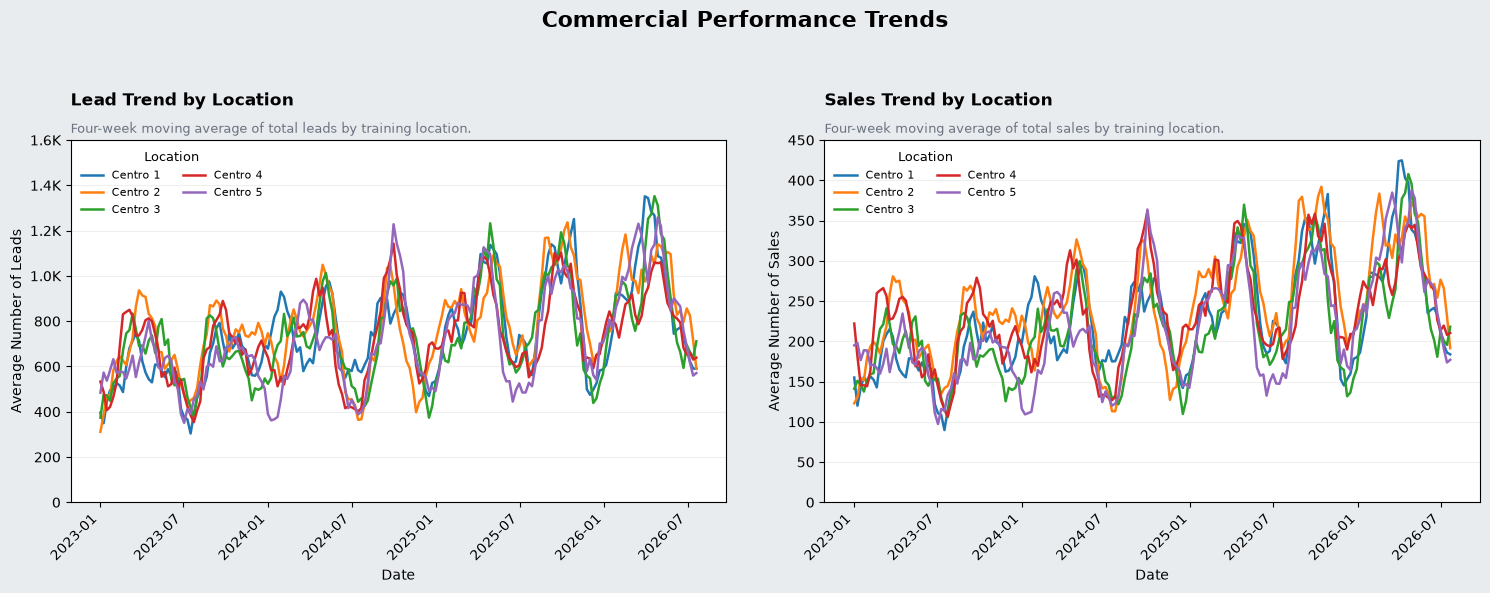

In [27]:
commercial_temporal_trend_charts = {
    "leads": {
        "df": commercial_location_weekly_df,
        "date_column": "date",
        "value_column": "total_leads",
        "group_column": "local",
        "rolling_window": 4,
        "title": "Lead Trend by Location",
        "description": (
            "Four-week moving average of total leads by training location."
        ),
        "ylabel": "Average Number of Leads"
    },

    "sales": {
        "df": commercial_location_weekly_df,
        "date_column": "date",
        "value_column": "total_sales",
        "group_column": "local",
        "rolling_window": 4,
        "title": "Sales Trend by Location",
        "description": (
            "Four-week moving average of total sales by training location."
        ),
        "ylabel": "Average Number of Sales"
    }
}


plot_commercial_trends(
    charts=commercial_temporal_trend_charts,
    title="Commercial Performance Trends",
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

In [28]:
commercial_total_weekly_df = (
    commercial_weekly_df
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        total_leads=(
            "total_leads",
            "sum"
        ),

        total_sales=(
            "total_sales",
            "sum"
        )
    )
    .assign(
        series="Total"
    )
    .sort_values("date")
    .reset_index(drop=True)
)

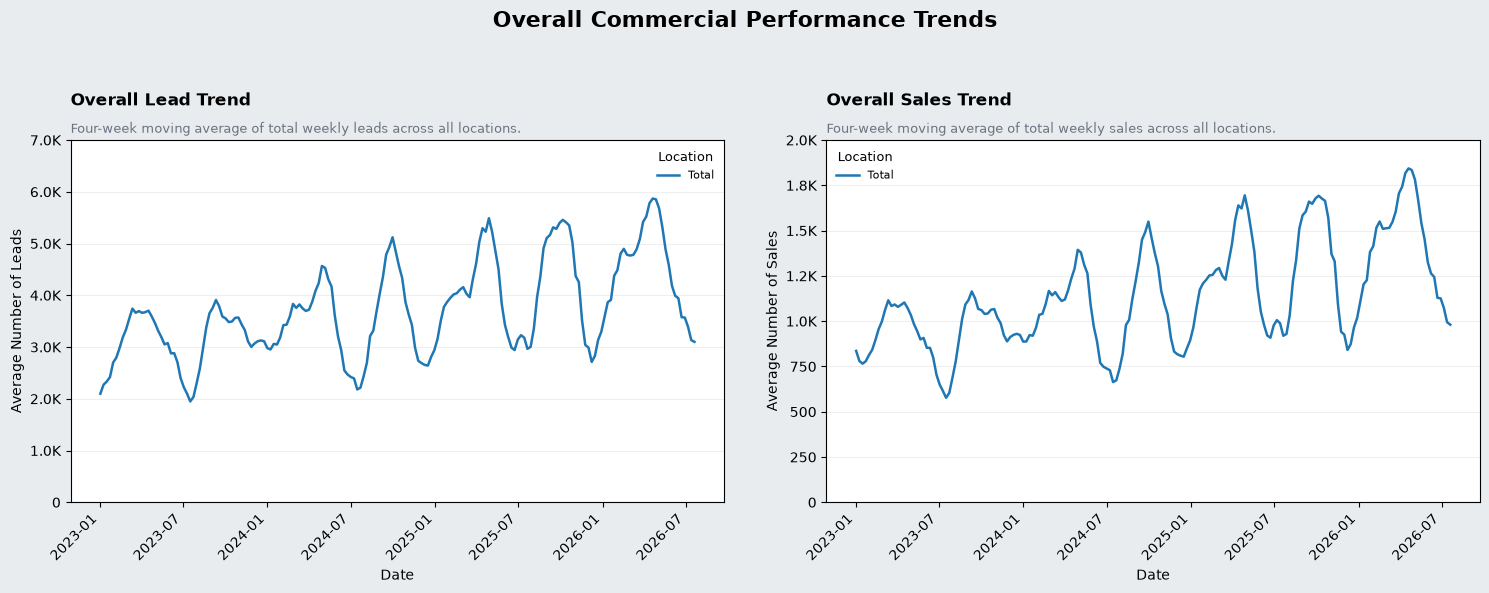

In [29]:
commercial_total_temporal_charts = {
    "leads": {
        "df": commercial_total_weekly_df,
        "date_column": "date",
        "value_column": "total_leads",
        "group_column": "series",
        "rolling_window": 4,
        "title": "Overall Lead Trend",
        "description": (
            "Four-week moving average of total weekly leads across all locations."
        ),
        "ylabel": "Average Number of Leads"
    },

    "sales": {
        "df": commercial_total_weekly_df,
        "date_column": "date",
        "value_column": "total_sales",
        "group_column": "series",
        "rolling_window": 4,
        "title": "Overall Sales Trend",
        "description": (
            "Four-week moving average of total weekly sales across all locations."
        ),
        "ylabel": "Average Number of Sales"
    }
}


plot_commercial_trends(
    charts=commercial_total_temporal_charts,
    title="Overall Commercial Performance Trends",
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

## Commercial feature engineering

Four complementary dimensions are created for each course-location combination:

1. **Volume:** total and average weekly leads and sales;
2. **Conversion:** effectiveness in transforming leads into completed sales;
3. **Regularity:** proportion of weeks containing leads or sales;
4. **Growth:** average weekly change in lead and sales volumes.

Each dimension is calculated separately for the last 13 weeks and the historical period.

In [30]:
commercial_weekly_df["week_with_leads"] = (
    commercial_weekly_df["total_leads"]
    .gt(0)
    .astype(int)
)


commercial_weekly_df["week_with_sales"] = (
    commercial_weekly_df["total_sales"]
    .gt(0)
    .astype(int)
)

In [31]:
commercial_weekly_df["weekly_conversion_rate"] = (
    commercial_weekly_df["total_sales"]
    .div(
        commercial_weekly_df["total_leads"]
        .where(
            commercial_weekly_df["total_leads"]
            .ne(0)
        )
    )
    .mul(100)
)

In [32]:
commercial_weekly_df["leads_weekly_change"] = (
    commercial_weekly_df
    .groupby(group_columns)["total_leads"]
    .diff()
)


commercial_weekly_df["sales_weekly_change"] = (
    commercial_weekly_df
    .groupby(group_columns)["total_sales"]
    .diff()
)

### Volume

Commercial volume is represented by:

- total leads;
- total sales;
- average weekly leads;
- average weekly sales.

The indicators distinguish the absolute scale of commercial activity from its typical weekly level. They are calculated separately for the recent and historical periods.

In [33]:
volume_last_13w_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("last_13w")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        total_leads_last_13w=(
            "total_leads",
            "sum"
        ),

        total_sales_last_13w=(
            "total_sales",
            "sum"
        ),

        avg_leads_last_13w=(
            "total_leads",
            "mean"
        ),

        avg_sales_last_13w=(
            "total_sales",
            "mean"
        )
    )
)

In [34]:
volume_historical_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        total_leads_historical=(
            "total_leads",
            "sum"
        ),

        total_sales_historical=(
            "total_sales",
            "sum"
        ),

        avg_leads_historical=(
            "total_leads",
            "mean"
        ),

        avg_sales_historical=(
            "total_sales",
            "mean"
        )
    )
)

In [35]:
commercial_volume_features_df = (
    course_local_combinations
    .merge(
        volume_last_13w_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        volume_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


commercial_volume_features_df

,course_id,course_name,course_area,local,total_leads_last_13w,total_sales_last_13w,avg_leads_last_13w,avg_sales_last_13w,total_leads_historical,total_sales_historical,avg_leads_historical,avg_sales_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,886,252,68.153846,19.384615,10560,2894,61.040462,16.728324
1,CYB,Cibersegurança Básica,Informática,Centro 2,1466,434,112.769231,33.384615,11088,3188,64.092486,18.427746
2,CYB,Cibersegurança Básica,Informática,Centro 3,1028,281,79.076923,21.615385,9051,2391,52.317919,13.820809
3,CYB,Cibersegurança Básica,Informática,Centro 4,1651,496,127.000000,38.153846,13502,3921,78.046243,22.664740
4,CYB,Cibersegurança Básica,Informática,Centro 5,560,156,43.076923,12.000000,8417,2252,48.653179,13.017341
...,...,...,...,...,...,...,...,...,...,...,...,...
115,VND,Vendas e Negociação,Comercial,Centro 1,365,114,28.076923,8.769231,4817,1411,27.843931,8.156069
116,VND,Vendas e Negociação,Comercial,Centro 2,455,147,35.000000,11.307692,6836,2133,39.514451,12.329480
117,VND,Vendas e Negociação,Comercial,Centro 3,150,46,11.538462,3.538462,3658,1055,21.144509,6.098266
118,VND,Vendas e Negociação,Comercial,Centro 4,470,154,36.153846,11.846154,5959,1909,34.445087,11.034682


### Conversion

Conversion measures the relationship between completed sales and generated leads.

Two indicators are calculated:

- the conversion rate obtained from total sales divided by total leads in the period;
- the average of the weekly conversion rates.

The total rate describes overall commercial effectiveness, while the weekly average reduces the influence of individual high-volume weeks.

In [36]:
conversion_last_13w_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("last_13w")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        total_leads_period=(
            "total_leads",
            "sum"
        ),

        total_sales_period=(
            "total_sales",
            "sum"
        ),

        avg_conversion_rate_last_13w=(
            "weekly_conversion_rate",
            "mean"
        )
    )
    .assign(
        total_conversion_rate_last_13w=lambda df:
            df["total_sales_period"]
            .div(
                df["total_leads_period"]
                .where(
                    df["total_leads_period"]
                    .ne(0)
                )
            )
            .mul(100)
            .fillna(0),

        avg_conversion_rate_last_13w=lambda df:
            df["avg_conversion_rate_last_13w"]
            .fillna(0)
    )
    .drop(
        columns=[
            "total_leads_period",
            "total_sales_period"
        ]
    )
)

In [37]:
conversion_historical_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        total_leads_period=(
            "total_leads",
            "sum"
        ),

        total_sales_period=(
            "total_sales",
            "sum"
        ),

        avg_conversion_rate_historical=(
            "weekly_conversion_rate",
            "mean"
        )
    )
    .assign(
        total_conversion_rate_historical=lambda df:
            df["total_sales_period"]
            .div(
                df["total_leads_period"]
                .where(
                    df["total_leads_period"]
                    .ne(0)
                )
            )
            .mul(100)
            .fillna(0),

        avg_conversion_rate_historical=lambda df:
            df["avg_conversion_rate_historical"]
            .fillna(0)
    )
    .drop(
        columns=[
            "total_leads_period",
            "total_sales_period"
        ]
    )
)

In [38]:
commercial_conversion_features_df = (
    course_local_combinations
    .merge(
        conversion_last_13w_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        conversion_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


commercial_conversion_features_df

,course_id,course_name,course_area,local,avg_conversion_rate_last_13w,total_conversion_rate_last_13w,avg_conversion_rate_historical,total_conversion_rate_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,28.255751,28.442438,26.935370,27.405303
1,CYB,Cibersegurança Básica,Informática,Centro 2,29.129160,29.604366,28.191865,28.751804
2,CYB,Cibersegurança Básica,Informática,Centro 3,27.278431,27.334630,25.790080,26.416971
3,CYB,Cibersegurança Básica,Informática,Centro 4,29.060442,30.042399,29.457639,29.040142
4,CYB,Cibersegurança Básica,Informática,Centro 5,27.959116,27.857143,26.115435,26.755376
...,...,...,...,...,...,...,...,...
115,VND,Vendas e Negociação,Comercial,Centro 1,31.590103,31.232877,28.072998,29.292091
116,VND,Vendas e Negociação,Comercial,Centro 2,31.790721,32.307692,31.030425,31.202458
117,VND,Vendas e Negociação,Comercial,Centro 3,29.108041,30.666667,27.962653,28.840897
118,VND,Vendas e Negociação,Comercial,Centro 4,31.033298,32.765957,31.593592,32.035576


### Regularity

Regularity measures the proportion of weeks containing commercial activity.

For each course-location combination, the analysis calculates:

- the percentage of weeks with at least one lead;
- the percentage of weeks with at least one sale.

Higher percentages indicate more consistent commercial demand, while lower percentages indicate intermittent or occasional activity.

In [39]:
regularity_last_13w_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("last_13w")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        pct_with_leads_last_13w=(
            "week_with_leads",
            "mean"
        ),

        pct_with_sales_last_13w=(
            "week_with_sales",
            "mean"
        )
    )
    .assign(
        pct_with_leads_last_13w=lambda df:
            df["pct_with_leads_last_13w"]
            .mul(100),

        pct_with_sales_last_13w=lambda df:
            df["pct_with_sales_last_13w"]
            .mul(100)
    )
)

In [40]:
regularity_historical_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        pct_with_leads_historical=(
            "week_with_leads",
            "mean"
        ),

        pct_with_sales_historical=(
            "week_with_sales",
            "mean"
        )
    )
    .assign(
        pct_with_leads_historical=lambda df:
            df["pct_with_leads_historical"]
            .mul(100),

        pct_with_sales_historical=lambda df:
            df["pct_with_sales_historical"]
            .mul(100)
    )
)

In [41]:
commercial_regularity_features_df = (
    course_local_combinations
    .merge(
        regularity_last_13w_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        regularity_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


commercial_regularity_features_df

,course_id,course_name,course_area,local,pct_with_leads_last_13w,pct_with_sales_last_13w,pct_with_leads_historical,pct_with_sales_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,100.000000,100.000000,79.768786,79.768786
1,CYB,Cibersegurança Básica,Informática,Centro 2,100.000000,100.000000,88.439306,88.439306
2,CYB,Cibersegurança Básica,Informática,Centro 3,84.615385,84.615385,83.815029,83.815029
3,CYB,Cibersegurança Básica,Informática,Centro 4,100.000000,100.000000,92.485549,92.485549
4,CYB,Cibersegurança Básica,Informática,Centro 5,69.230769,69.230769,76.300578,76.300578
...,...,...,...,...,...,...,...,...
115,VND,Vendas e Negociação,Comercial,Centro 1,69.230769,69.230769,70.520231,69.942197
116,VND,Vendas e Negociação,Comercial,Centro 2,100.000000,100.000000,77.456647,77.456647
117,VND,Vendas e Negociação,Comercial,Centro 3,30.769231,30.769231,57.225434,57.225434
118,VND,Vendas e Negociação,Comercial,Centro 4,69.230769,69.230769,78.034682,78.034682


### Growth

Growth is represented by the average weekly change in lead and sales volumes.

A positive value indicates that commercial activity increased, on average, from one week to the next. A negative value indicates decreasing activity, while a value close to zero indicates relative stability.

The indicators are calculated separately for the recent and historical periods.

In [42]:
growth_last_13w_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("last_13w")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        leads_weekly_change_avg_last_13w=(
            "leads_weekly_change",
            "mean"
        ),

        sales_weekly_change_avg_last_13w=(
            "sales_weekly_change",
            "mean"
        )
    )
)

In [43]:
growth_historical_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        leads_weekly_change_avg_historical=(
            "leads_weekly_change",
            "mean"
        ),

        sales_weekly_change_avg_historical=(
            "sales_weekly_change",
            "mean"
        )
    )
)

In [44]:
commercial_growth_features_df = (
    course_local_combinations
    .merge(
        growth_last_13w_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        growth_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


commercial_growth_features_df

,course_id,course_name,course_area,local,leads_weekly_change_avg_last_13w,sales_weekly_change_avg_last_13w,leads_weekly_change_avg_historical,sales_weekly_change_avg_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,1.615385,0.461538,0.226744,0.058140
1,CYB,Cibersegurança Básica,Informática,Centro 2,-11.615385,-3.615385,0.709302,0.209302
2,CYB,Cibersegurança Básica,Informática,Centro 3,2.076923,0.615385,0.482558,0.116279
3,CYB,Cibersegurança Básica,Informática,Centro 4,-3.230769,-0.923077,1.087209,0.319767
4,CYB,Cibersegurança Básica,Informática,Centro 5,-0.846154,-0.230769,-0.145349,-0.058140
...,...,...,...,...,...,...,...,...
115,VND,Vendas e Negociação,Comercial,Centro 1,8.615385,2.615385,-0.034884,-0.011628
116,VND,Vendas e Negociação,Comercial,Centro 2,-4.846154,-1.615385,0.354651,0.110465
117,VND,Vendas e Negociação,Comercial,Centro 3,-8.153846,-2.538462,0.424419,0.116279
118,VND,Vendas e Negociação,Comercial,Centro 4,1.000000,0.384615,0.325581,0.104651


## Consolidated commercial features

The four feature groups are combined into a single dataset containing one row for each course-location combination.

The resulting analytical base contains 120 combinations and 20 recent and historical commercial features covering volume, conversion, regularity, and growth.

In [45]:
commercial_features_df = (
    course_local_combinations
    .merge(
        commercial_volume_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_conversion_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_regularity_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_growth_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        ["local", "course_id"]
    )
    .reset_index(drop=True)
)

In [46]:
commercial_features_df = commercial_features_df[
    group_columns + [

        "total_leads_last_13w",
        "total_leads_historical",
        "total_sales_last_13w",
        "total_sales_historical",

        "avg_leads_last_13w",
        "avg_leads_historical",
        "avg_sales_last_13w",
        "avg_sales_historical",

        "total_conversion_rate_last_13w",
        "total_conversion_rate_historical",
        "avg_conversion_rate_last_13w",
        "avg_conversion_rate_historical",

        "pct_with_leads_last_13w",
        "pct_with_leads_historical",
        "pct_with_sales_last_13w",
        "pct_with_sales_historical",

        "leads_weekly_change_avg_last_13w",
        "leads_weekly_change_avg_historical",
        "sales_weekly_change_avg_last_13w",
        "sales_weekly_change_avg_historical"
    ]
]

commercial_features_df = commercial_features_df.round(2)


commercial_features_df

,course_id,course_name,course_area,local,total_leads_last_13w,total_leads_historical,total_sales_last_13w,total_sales_historical,avg_leads_last_13w,avg_leads_historical,...,avg_conversion_rate_last_13w,avg_conversion_rate_historical,pct_with_leads_last_13w,pct_with_leads_historical,pct_with_sales_last_13w,pct_with_sales_historical,leads_weekly_change_avg_last_13w,leads_weekly_change_avg_historical,sales_weekly_change_avg_last_13w,sales_weekly_change_avg_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,886,10560,252,2894,68.15,61.04,...,28.26,26.94,100.00,79.77,100.00,79.77,1.62,0.23,0.46,0.06
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,304,4524,99,1414,23.38,26.15,...,32.44,30.46,76.92,68.21,76.92,67.63,0.54,0.00,0.15,0.00
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,562,6173,189,2004,43.23,35.68,...,37.39,32.34,100.00,75.72,100.00,75.72,2.00,0.14,0.62,0.05
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,241,4662,70,1296,18.54,26.95,...,27.98,26.94,53.85,64.16,53.85,64.16,0.00,-0.10,0.00,-0.03
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,202,4859,64,1487,15.54,28.09,...,31.52,29.65,38.46,69.94,38.46,69.94,-2.46,0.08,-0.77,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,749,6947,251,2285,57.62,40.16,...,32.69,32.47,92.31,78.61,92.31,78.61,-11.23,0.65,-3.92,0.20
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,190,3090,55,866,14.62,17.86,...,27.71,27.44,53.85,53.76,53.85,53.76,5.00,-0.09,1.54,-0.03
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,686,7734,226,2480,52.77,44.71,...,33.09,31.43,76.92,87.86,76.92,87.86,-8.15,0.35,-2.62,0.08
118,TUR,Atendimento Turístico,Turismo,Centro 5,319,4253,101,1265,24.54,24.58,...,31.90,28.56,61.54,67.63,61.54,67.63,-10.77,0.84,-3.31,0.26


## Commercial pressure score

The commercial features are converted into percentile-based pressure scores ranging from 0 to 100.

The score combines:

- **Volume — 35%:** average weekly leads and sales;
- **Conversion — 25%:** total and average weekly conversion rates;
- **Regularity — 25%:** proportion of weeks containing leads and sales;
- **Growth — 15%:** average weekly change in lead and sales volumes.

Volume receives the greatest weight because it most directly represents the scale of market demand. Conversion and regularity distinguish effective and sustained demand from isolated commercial activity.

Recent activity receives a weight of **60%**, while historical activity receives **40%**. This gives greater relevance to current commercial conditions without discarding the long-term pattern.

All scores are relative to the 120 combinations in this dataset. A high score therefore indicates comparatively greater commercial pressure rather than a universal demand threshold.

In [47]:
score_group_columns = [
    "course_id",
    "course_name",
    "course_area",
    "local"
]


recent_weight = 0.60
historical_weight = 0.40


dimension_weights = {
    "volume": 0.35,
    "conversion": 0.25,
    "regularity": 0.25,
    "growth": 0.15
}


assert round(sum(dimension_weights.values()), 10) == 1, (
    "Dimension weights must add up to 1."
)


assert recent_weight + historical_weight == 1, (
    "Period weights must add up to 1."
)

In [48]:
def create_percentile_score(series, inverse=False):

    values = pd.to_numeric(series, errors="coerce")

    scores = values.rank(pct=True, method="average", ascending=not inverse).mul(100)

    scores = scores.mask(values.eq(0), 0)

    return scores.fillna(0)

In [49]:
commercial_score_combinations = (
    commercial_features_df[
        score_group_columns
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

### Dimension scoring

Each raw commercial feature is converted into a percentile score.

Higher volume, conversion, regularity, and positive growth produce higher commercial-pressure scores.

Negative growth values are clipped to zero before ranking. This means declining lead or sales activity does not create positive growth pressure.

In [50]:
commercial_volume_score_df = (
    commercial_features_df[
        score_group_columns + [
            "avg_leads_last_13w",
            "avg_leads_historical",
            "avg_sales_last_13w",
            "avg_sales_historical"
        ]
    ]
    .copy()
    .assign(
        commercial_volume_last_13w_score=lambda df: (
            create_percentile_score(
                df["avg_leads_last_13w"]
            )
            .add(
                create_percentile_score(
                    df["avg_sales_last_13w"]
                )
            )
            .div(2)
        ),

        commercial_volume_historical_score=lambda df: (
            create_percentile_score(
                df["avg_leads_historical"]
            )
            .add(
                create_percentile_score(
                    df["avg_sales_historical"]
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "commercial_volume_last_13w_score",
            "commercial_volume_historical_score"
        ]
    ]
)


commercial_volume_score_df

,course_id,course_name,course_area,local,commercial_volume_last_13w_score,commercial_volume_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,94.583333,95.416667
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,37.500000,40.625000
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,80.833333,75.833333
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,20.208333,38.958333
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,15.208333,48.541667
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,91.666667,85.833333
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,10.416667,11.666667
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,87.916667,88.750000
118,TUR,Atendimento Turístico,Turismo,Centro 5,40.833333,30.833333


In [51]:
commercial_conversion_score_df = (
    commercial_features_df[
        score_group_columns + [
            "total_conversion_rate_last_13w",
            "total_conversion_rate_historical",
            "avg_conversion_rate_last_13w",
            "avg_conversion_rate_historical"
        ]
    ]
    .copy()
    .assign(
        commercial_conversion_last_13w_score=lambda df: (
            create_percentile_score(
                df["total_conversion_rate_last_13w"]
            )
            .add(
                create_percentile_score(
                    df["avg_conversion_rate_last_13w"]
                )
            )
            .div(2)
        ),

        commercial_conversion_historical_score=lambda df: (
            create_percentile_score(
                df["total_conversion_rate_historical"]
            )
            .add(
                create_percentile_score(
                    df["avg_conversion_rate_historical"]
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "commercial_conversion_last_13w_score",
            "commercial_conversion_historical_score"
        ]
    ]
)


commercial_conversion_score_df

,course_id,course_name,course_area,local,commercial_conversion_last_13w_score,commercial_conversion_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,16.666667,13.125000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,61.250000,57.916667
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,86.250000,74.166667
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,17.291667,14.791667
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,43.125000,47.291667
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,70.000000,77.083333
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,15.000000,17.500000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,68.750000,65.416667
118,TUR,Atendimento Turístico,Turismo,Centro 5,48.333333,38.333333


In [52]:
commercial_regularity_score_df = (
    commercial_features_df[
        score_group_columns + [
            "pct_with_leads_last_13w",
            "pct_with_leads_historical",
            "pct_with_sales_last_13w",
            "pct_with_sales_historical"
        ]
    ]
    .copy()
    .assign(
        commercial_regularity_last_13w_score=lambda df: (
            create_percentile_score(
                df["pct_with_leads_last_13w"]
            )
            .add(
                create_percentile_score(
                    df["pct_with_sales_last_13w"]
                )
            )
            .div(2)
        ),

        commercial_regularity_historical_score=lambda df: (
            create_percentile_score(
                df["pct_with_leads_historical"]
            )
            .add(
                create_percentile_score(
                    df["pct_with_sales_historical"]
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "commercial_regularity_last_13w_score",
            "commercial_regularity_historical_score"
        ]
    ]
)


commercial_regularity_score_df

,course_id,course_name,course_area,local,commercial_regularity_last_13w_score,commercial_regularity_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,95.416667,81.250000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,56.875000,44.583333
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,95.416667,69.791667
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,18.750000,33.958333
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,7.083333,51.250000
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,84.166667,77.083333
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,18.750000,10.625000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,56.875000,95.416667
118,TUR,Atendimento Turístico,Turismo,Centro 5,29.791667,43.125000


In [53]:
commercial_growth_score_df = (
    commercial_features_df[
        score_group_columns + [
            "leads_weekly_change_avg_last_13w",
            "leads_weekly_change_avg_historical",
            "sales_weekly_change_avg_last_13w",
            "sales_weekly_change_avg_historical"
        ]
    ]
    .copy()
    .assign(
        commercial_growth_last_13w_score=lambda df: (
            create_percentile_score(
                df["leads_weekly_change_avg_last_13w"]
                .clip(lower=0)
            )
            .add(
                create_percentile_score(
                    df["sales_weekly_change_avg_last_13w"]
                    .clip(lower=0)
                )
            )
            .div(2)
        ),

        commercial_growth_historical_score=lambda df: (
            create_percentile_score(
                df["leads_weekly_change_avg_historical"]
                .clip(lower=0)
            )
            .add(
                create_percentile_score(
                    df["sales_weekly_change_avg_historical"]
                    .clip(lower=0)
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "commercial_growth_last_13w_score",
            "commercial_growth_historical_score"
        ]
    ]
)


commercial_growth_score_df

,course_id,course_name,course_area,local,commercial_growth_last_13w_score,commercial_growth_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,87.916667,63.125000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,82.916667,0.000000
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,90.208333,53.333333
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,0.000000,0.000000
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,0.000000,42.708333
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,0.000000,92.500000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,95.833333,0.000000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,0.000000,73.333333
118,TUR,Atendimento Turístico,Turismo,Centro 5,0.000000,98.333333


### Score integration

The four dimension scores are merged for every course-location combination.

Separate recent and historical scores are first calculated using the dimension weights. The two periods are then combined to produce the final commercial scores and weighted contributions.

In [54]:
commercial_dimension_scores_df = (
    commercial_score_combinations
    .merge(
        commercial_volume_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_conversion_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_regularity_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_growth_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
)


commercial_dimension_scores_df

,course_id,course_name,course_area,local,commercial_volume_last_13w_score,commercial_volume_historical_score,commercial_conversion_last_13w_score,commercial_conversion_historical_score,commercial_regularity_last_13w_score,commercial_regularity_historical_score,commercial_growth_last_13w_score,commercial_growth_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,94.583333,95.416667,16.666667,13.125000,95.416667,81.250000,87.916667,63.125000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,37.500000,40.625000,61.250000,57.916667,56.875000,44.583333,82.916667,0.000000
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,80.833333,75.833333,86.250000,74.166667,95.416667,69.791667,90.208333,53.333333
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,20.208333,38.958333,17.291667,14.791667,18.750000,33.958333,0.000000,0.000000
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,15.208333,48.541667,43.125000,47.291667,7.083333,51.250000,0.000000,42.708333
...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,91.666667,85.833333,70.000000,77.083333,84.166667,77.083333,0.000000,92.500000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,10.416667,11.666667,15.000000,17.500000,18.750000,10.625000,95.833333,0.000000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,87.916667,88.750000,68.750000,65.416667,56.875000,95.416667,0.000000,73.333333
118,TUR,Atendimento Turístico,Turismo,Centro 5,40.833333,30.833333,48.333333,38.333333,29.791667,43.125000,0.000000,98.333333


In [55]:
commercial_dimension_scores_df = (
    commercial_dimension_scores_df
    .assign(
        commercial_last_13w_score=lambda df: (
            df["commercial_volume_last_13w_score"]
            .mul(dimension_weights["volume"])

            .add(
                df["commercial_conversion_last_13w_score"]
                .mul(dimension_weights["conversion"])
            )

            .add(
                df["commercial_regularity_last_13w_score"]
                .mul(dimension_weights["regularity"])
            )

            .add(
                df["commercial_growth_last_13w_score"]
                .mul(dimension_weights["growth"])
            )
        ),

        commercial_historical_score=lambda df: (
            df["commercial_volume_historical_score"]
            .mul(dimension_weights["volume"])

            .add(
                df["commercial_conversion_historical_score"]
                .mul(dimension_weights["conversion"])
            )

            .add(
                df["commercial_regularity_historical_score"]
                .mul(dimension_weights["regularity"])
            )

            .add(
                df["commercial_growth_historical_score"]
                .mul(dimension_weights["growth"])
            )
        )
    )
)


commercial_dimension_scores_df

,course_id,course_name,course_area,local,commercial_volume_last_13w_score,commercial_volume_historical_score,commercial_conversion_last_13w_score,commercial_conversion_historical_score,commercial_regularity_last_13w_score,commercial_regularity_historical_score,commercial_growth_last_13w_score,commercial_growth_historical_score,commercial_last_13w_score,commercial_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,94.583333,95.416667,16.666667,13.125000,95.416667,81.250000,87.916667,63.125000,74.312500,66.458333
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,37.500000,40.625000,61.250000,57.916667,56.875000,44.583333,82.916667,0.000000,55.093750,39.843750
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,80.833333,75.833333,86.250000,74.166667,95.416667,69.791667,90.208333,53.333333,87.239583,70.531250
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,20.208333,38.958333,17.291667,14.791667,18.750000,33.958333,0.000000,0.000000,16.083333,25.822917
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,15.208333,48.541667,43.125000,47.291667,7.083333,51.250000,0.000000,42.708333,17.875000,48.031250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,91.666667,85.833333,70.000000,77.083333,84.166667,77.083333,0.000000,92.500000,70.625000,82.458333
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,10.416667,11.666667,15.000000,17.500000,18.750000,10.625000,95.833333,0.000000,26.458333,11.114583
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,87.916667,88.750000,68.750000,65.416667,56.875000,95.416667,0.000000,73.333333,62.177083,82.270833
118,TUR,Atendimento Turístico,Turismo,Centro 5,40.833333,30.833333,48.333333,38.333333,29.791667,43.125000,0.000000,98.333333,33.822917,45.906250


In [56]:
commercial_dimension_scores_df = (
    commercial_dimension_scores_df
    .assign(
        commercial_volume_score=lambda df: (
            df["commercial_volume_last_13w_score"]
            .mul(recent_weight)
            .add(
                df["commercial_volume_historical_score"]
                .mul(historical_weight)
            )
        ),

        commercial_conversion_score=lambda df: (
            df["commercial_conversion_last_13w_score"]
            .mul(recent_weight)
            .add(
                df["commercial_conversion_historical_score"]
                .mul(historical_weight)
            )
        ),

        commercial_regularity_score=lambda df: (
            df["commercial_regularity_last_13w_score"]
            .mul(recent_weight)
            .add(
                df["commercial_regularity_historical_score"]
                .mul(historical_weight)
            )
        ),

        commercial_growth_score=lambda df: (
            df["commercial_growth_last_13w_score"]
            .mul(recent_weight)
            .add(
                df["commercial_growth_historical_score"]
                .mul(historical_weight)
            )
        )
    )
)


commercial_dimension_scores_df

,course_id,course_name,course_area,local,commercial_volume_last_13w_score,commercial_volume_historical_score,commercial_conversion_last_13w_score,commercial_conversion_historical_score,commercial_regularity_last_13w_score,commercial_regularity_historical_score,commercial_growth_last_13w_score,commercial_growth_historical_score,commercial_last_13w_score,commercial_historical_score,commercial_volume_score,commercial_conversion_score,commercial_regularity_score,commercial_growth_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,94.583333,95.416667,16.666667,13.125000,95.416667,81.250000,87.916667,63.125000,74.312500,66.458333,94.916667,15.250000,89.750000,78.000000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,37.500000,40.625000,61.250000,57.916667,56.875000,44.583333,82.916667,0.000000,55.093750,39.843750,38.750000,59.916667,51.958333,49.750000
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,80.833333,75.833333,86.250000,74.166667,95.416667,69.791667,90.208333,53.333333,87.239583,70.531250,78.833333,81.416667,85.166667,75.458333
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,20.208333,38.958333,17.291667,14.791667,18.750000,33.958333,0.000000,0.000000,16.083333,25.822917,27.708333,16.291667,24.833333,0.000000
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,15.208333,48.541667,43.125000,47.291667,7.083333,51.250000,0.000000,42.708333,17.875000,48.031250,28.541667,44.791667,24.750000,17.083333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,91.666667,85.833333,70.000000,77.083333,84.166667,77.083333,0.000000,92.500000,70.625000,82.458333,89.333333,72.833333,81.333333,37.000000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,10.416667,11.666667,15.000000,17.500000,18.750000,10.625000,95.833333,0.000000,26.458333,11.114583,10.916667,16.000000,15.500000,57.500000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,87.916667,88.750000,68.750000,65.416667,56.875000,95.416667,0.000000,73.333333,62.177083,82.270833,88.250000,67.416667,72.291667,29.333333
118,TUR,Atendimento Turístico,Turismo,Centro 5,40.833333,30.833333,48.333333,38.333333,29.791667,43.125000,0.000000,98.333333,33.822917,45.906250,36.833333,44.333333,35.125000,39.333333


In [57]:
commercial_dimension_scores_df = (
    commercial_dimension_scores_df
    .assign(
        commercial_volume_contribution=lambda df:
            df["commercial_volume_score"]
            .mul(dimension_weights["volume"]),

        commercial_conversion_contribution=lambda df:
            df["commercial_conversion_score"]
            .mul(dimension_weights["conversion"]),

        commercial_regularity_contribution=lambda df:
            df["commercial_regularity_score"]
            .mul(dimension_weights["regularity"]),

        commercial_growth_contribution=lambda df:
            df["commercial_growth_score"]
            .mul(dimension_weights["growth"]),

        commercial_base_score=lambda df: (
            df["commercial_last_13w_score"]
            .mul(recent_weight)
            .add(
                df["commercial_historical_score"]
                .mul(historical_weight)
            )
        )
    )
)

In [58]:
commercial_dimension_scores_df = (
    commercial_dimension_scores_df
    .assign(
        commercial_pressure_tier=lambda df:
            pd.cut(
                df["commercial_base_score"],
                bins=[
                    0,
                    25,
                    50,
                    75,
                    100
                ],
                labels=[
                    "Low",
                    "Lower-middle",
                    "Upper-middle",
                    "High"
                ],
                include_lowest=True
            ),

        commercial_main_pressure_driver=lambda df:
            df[
                [
                    "commercial_volume_contribution",
                    "commercial_conversion_contribution",
                    "commercial_regularity_contribution",
                    "commercial_growth_contribution"
                ]
            ]
            .idxmax(axis=1)
            .map(
                {
                    "commercial_volume_contribution":
                        "Volume",

                    "commercial_conversion_contribution":
                        "Conversion",

                    "commercial_regularity_contribution":
                        "Regularity",

                    "commercial_growth_contribution":
                        "Growth"
                }
            )
    )
)

In [59]:
commercial_dimension_scores_df[
    "commercial_priority_rank"
] = (
    commercial_dimension_scores_df[
        "commercial_base_score"
    ]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

In [60]:
commercial_dimension_scores_df = (
    commercial_dimension_scores_df
    .round(2)
    .sort_values(
        "commercial_priority_rank"
    )
    .reset_index(drop=True)
)


commercial_dimension_scores_df

,course_id,course_name,course_area,local,commercial_volume_last_13w_score,commercial_volume_historical_score,commercial_conversion_last_13w_score,commercial_conversion_historical_score,commercial_regularity_last_13w_score,commercial_regularity_historical_score,...,commercial_regularity_score,commercial_growth_score,commercial_volume_contribution,commercial_conversion_contribution,commercial_regularity_contribution,commercial_growth_contribution,commercial_base_score,commercial_pressure_tier,commercial_main_pressure_driver,commercial_priority_rank
0,EXC,Excel Aplicado à Gestão,Informática,Centro 4,94.17,95.83,95.42,93.75,95.42,92.50,...,94.25,9.17,33.19,23.69,23.56,1.37,81.82,High,Volume,1
1,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,76.04,82.50,86.67,88.54,71.25,83.75,...,76.25,81.08,27.52,21.85,19.06,12.16,80.60,High,Volume,2
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,80.83,75.83,86.25,74.17,95.42,69.79,...,85.17,75.46,27.59,20.35,21.29,11.32,80.56,High,Volume,3
3,PBI,Power BI e Visualização de Dados,Informática,Centro 2,98.75,98.33,78.33,61.67,95.42,90.00,...,93.25,28.08,34.50,17.92,23.31,4.21,79.95,High,Volume,4
4,PBI,Power BI e Visualização de Dados,Informática,Centro 4,97.08,99.58,70.00,71.67,84.17,100.00,...,90.50,30.92,34.33,17.67,22.62,4.64,79.26,High,Volume,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,PRO,Gestão de Projetos,Gestão,Centro 5,25.83,37.50,2.08,2.92,29.79,20.62,...,26.12,0.00,10.68,0.60,6.53,0.00,17.81,Low,Volume,115
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 4,3.33,12.50,45.42,52.08,1.25,23.33,...,10.08,0.00,2.45,12.02,2.52,0.00,16.99,Low,Conversion,116
117,PRO,Gestão de Projetos,Gestão,Centro 3,23.12,26.25,4.17,2.50,5.00,9.79,...,6.92,36.67,8.53,0.87,1.73,5.50,16.64,Low,Volume,117
118,GES,Gestão de Equipas,Gestão,Centro 3,33.75,1.25,6.25,1.67,29.79,0.83,...,18.21,22.25,7.26,1.10,4.55,3.34,16.26,Low,Volume,118


In [61]:
commercial_scored_features_df = (
    commercial_features_df
    .merge(
        commercial_dimension_scores_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        "commercial_priority_rank"
    )
    .reset_index(drop=True)
)


commercial_scored_features_df

,course_id,course_name,course_area,local,total_leads_last_13w,total_leads_historical,total_sales_last_13w,total_sales_historical,avg_leads_last_13w,avg_leads_historical,...,commercial_regularity_score,commercial_growth_score,commercial_volume_contribution,commercial_conversion_contribution,commercial_regularity_contribution,commercial_growth_contribution,commercial_base_score,commercial_pressure_tier,commercial_main_pressure_driver,commercial_priority_rank
0,EXC,Excel Aplicado à Gestão,Informática,Centro 4,774,9133,278,3162,59.54,52.79,...,94.25,9.17,33.19,23.69,23.56,1.37,81.82,High,Volume,1
1,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,508,6562,176,2226,39.08,37.93,...,76.25,81.08,27.52,21.85,19.06,12.16,80.60,High,Volume,2
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,562,6173,189,2004,43.23,35.68,...,85.17,75.46,27.59,20.35,21.29,11.32,80.56,High,Volume,3
3,PBI,Power BI e Visualização de Dados,Informática,Centro 2,1347,11878,438,3751,103.62,68.66,...,93.25,28.08,34.50,17.92,23.31,4.21,79.95,High,Volume,4
4,PBI,Power BI e Visualização de Dados,Informática,Centro 4,954,13260,316,4282,73.38,76.65,...,90.50,30.92,34.33,17.67,22.62,4.64,79.26,High,Volume,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,PRO,Gestão de Projetos,Gestão,Centro 5,269,4760,72,1239,20.69,27.51,...,26.12,0.00,10.68,0.60,6.53,0.00,17.81,Low,Volume,115
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 4,79,3067,25,943,6.08,17.73,...,10.08,0.00,2.45,12.02,2.52,0.00,16.99,Low,Conversion,116
117,PRO,Gestão de Projetos,Gestão,Centro 3,261,4298,70,1103,20.08,24.84,...,6.92,36.67,8.53,0.87,1.73,5.50,16.64,Low,Volume,117
118,GES,Gestão de Equipas,Gestão,Centro 3,308,2060,85,536,23.69,11.91,...,18.21,22.25,7.26,1.10,4.55,3.34,16.26,Low,Volume,118


## Commercial pressure results

The final `commercial_base_score` is classified into four fixed levels:

- `Low`: 0–25;
- `Lower-middle`: above 25–50;
- `Upper-middle`: above 50–75;
- `High`: above 75–100.

The model also identifies the dimension with the greatest weighted contribution and assigns a commercial-priority rank to each combination.

The results are then examined by pressure level, main driver, location, professional area, and course.

In [62]:
tier_order = [
    "Low",
    "Lower-middle",
    "Upper-middle",
    "High"
]

commercial_tier_count_df = (
    commercial_dimension_scores_df[
        "commercial_pressure_tier"
    ]
    .value_counts()
    .reindex(
        tier_order,
        fill_value=0
    )
    .rename_axis(
        "commercial_pressure_tier"
    )
    .reset_index(
        name="commercial_count"
    )
    .assign(
        pct_commercial=lambda df:
            df["commercial_count"]
            .div(df["commercial_count"].sum())
            .mul(100)
    )
)


commercial_tier_count_df

,commercial_pressure_tier,commercial_count,pct_commercial
0,Low,17,14.166667
1,Lower-middle,49,40.833333
2,Upper-middle,45,37.500000
3,High,9,7.500000


In [63]:
commercial_driver_count_df = (
    commercial_dimension_scores_df
    .groupby(
        "commercial_main_pressure_driver",
        as_index=False
    )
    .agg(
        commercial_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_commercial=lambda df:
            df["commercial_count"]
            .div(df["commercial_count"].sum())
            .mul(100)
    )
    .sort_values(
        "commercial_count",
        ascending=False
    )
    .reset_index(drop=True)
)


commercial_driver_count_df

,commercial_main_pressure_driver,commercial_count,pct_commercial
0,Volume,71,59.166667
1,Conversion,44,36.666667
2,Regularity,4,3.333333
3,Growth,1,0.833333


In [64]:
priority_commercial_df = (
    commercial_dimension_scores_df
    .loc[
        commercial_dimension_scores_df[
            "commercial_pressure_tier"
        ]
        .isin([
            "Upper-middle",
            "High"
        ])
    ]
    .copy()
)

In [65]:
priority_commercial_local_count_df = (
    priority_commercial_df
    .groupby(
        "local",
        as_index=False
    )
    .agg(
        commercial_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_commercial=lambda df:
            df["commercial_count"]
            .div(df["commercial_count"].sum())
            .mul(100)
    )
    .sort_values(
        "commercial_count",
        ascending=False
    )
    .reset_index(drop=True)
)


priority_commercial_local_count_df

,local,commercial_count,pct_commercial
0,Centro 2,15,27.777778
1,Centro 1,11,20.370370
2,Centro 3,11,20.370370
3,Centro 4,9,16.666667
4,Centro 5,8,14.814815


In [66]:
priority_commercial_area_count_df = (
    priority_commercial_df
    .groupby(
        "course_area",
        as_index=False
    )
    .agg(
        commercial_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_commercial=lambda df:
            df["commercial_count"]
            .div(df["commercial_count"].sum())
            .mul(100)
    )
    .sort_values(
        "commercial_count",
        ascending=False
    )
    .reset_index(drop=True)
)


priority_commercial_area_count_df

,course_area,commercial_count,pct_commercial
0,Informática,15,27.777778
1,Segurança,10,18.518519
2,Alimentar,6,11.111111
3,Saúde e Segurança,5,9.259259
4,Logística,4,7.407407
5,Saúde,4,7.407407
6,Comercial,2,3.703704
7,Gestão,2,3.703704
8,Manutenção,2,3.703704
9,Turismo,2,3.703704


In [67]:
priority_commercial_course_count_df = (
    priority_commercial_df
    .groupby(
        [
            "course_id",
            "course_name"
        ],
        as_index=False
    )
    .agg(
        commercial_count=(
            "local",
            "nunique"
        )
    )
    .assign(
        pct_commercial=lambda df:
            df["commercial_count"]
            .div(df["commercial_count"].sum())
            .mul(100)
    )
    .sort_values(
        [
            "commercial_count",
            "course_id"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


priority_commercial_course_count_df

,course_id,course_name,commercial_count,pct_commercial
0,PBI,Power BI e Visualização de Dados,5,9.259259
1,PRI,Primeiros Socorros,5,9.259259
2,SST,Saúde e Segurança no Trabalho,5,9.259259
3,CYB,Cibersegurança Básica,4,7.407407
4,EXC,Excel Aplicado à Gestão,4,7.407407
5,HAC,Higiene e Segurança Alimentar,4,7.407407
6,LOG,Logística e Gestão de Armazém,4,7.407407
7,SEG,Segurança no Trabalho,4,7.407407
8,GER,Geriatria e Apoio ao Idoso,2,3.703704
9,HCP,HACCP Aplicado,2,3.703704


In [68]:
commercial_score_overview_charts = {
    "pressure_tier": {
        "df": commercial_tier_count_df,
        "label_column": "commercial_pressure_tier",
        "metric": "score",
        "sort": False,
        "title": "Commercial Pressure Tier",
        "description": (
            "Distribution of course-location combinations "
            "by commercial pressure level."
        )
    },

    "main_pressure_driver": {
        "df": commercial_driver_count_df,
        "label_column": "commercial_main_pressure_driver",
        "metric": "score",
        "title": "Main Commercial Pressure Driver",
        "description": (
            "Dimension with the highest weighted contribution "
            "to the commercial score."
        )
    },

    "priority_by_location": {
        "df": priority_commercial_local_count_df,
        "label_column": "local",
        "metric": "score",
        "title": "Priority Combinations by Location",
        "description": (
            "Upper-middle and high-pressure combinations "
            "distributed by location."
        )
    },

    "priority_by_course_area": {
        "df": priority_commercial_area_count_df,
        "label_column": "course_area",
        "metric": "score",
        "title": "Priority Combinations by Course Area",
        "description": (
            "Upper-middle and high-pressure combinations "
            "distributed by course area."
        )
    }
}

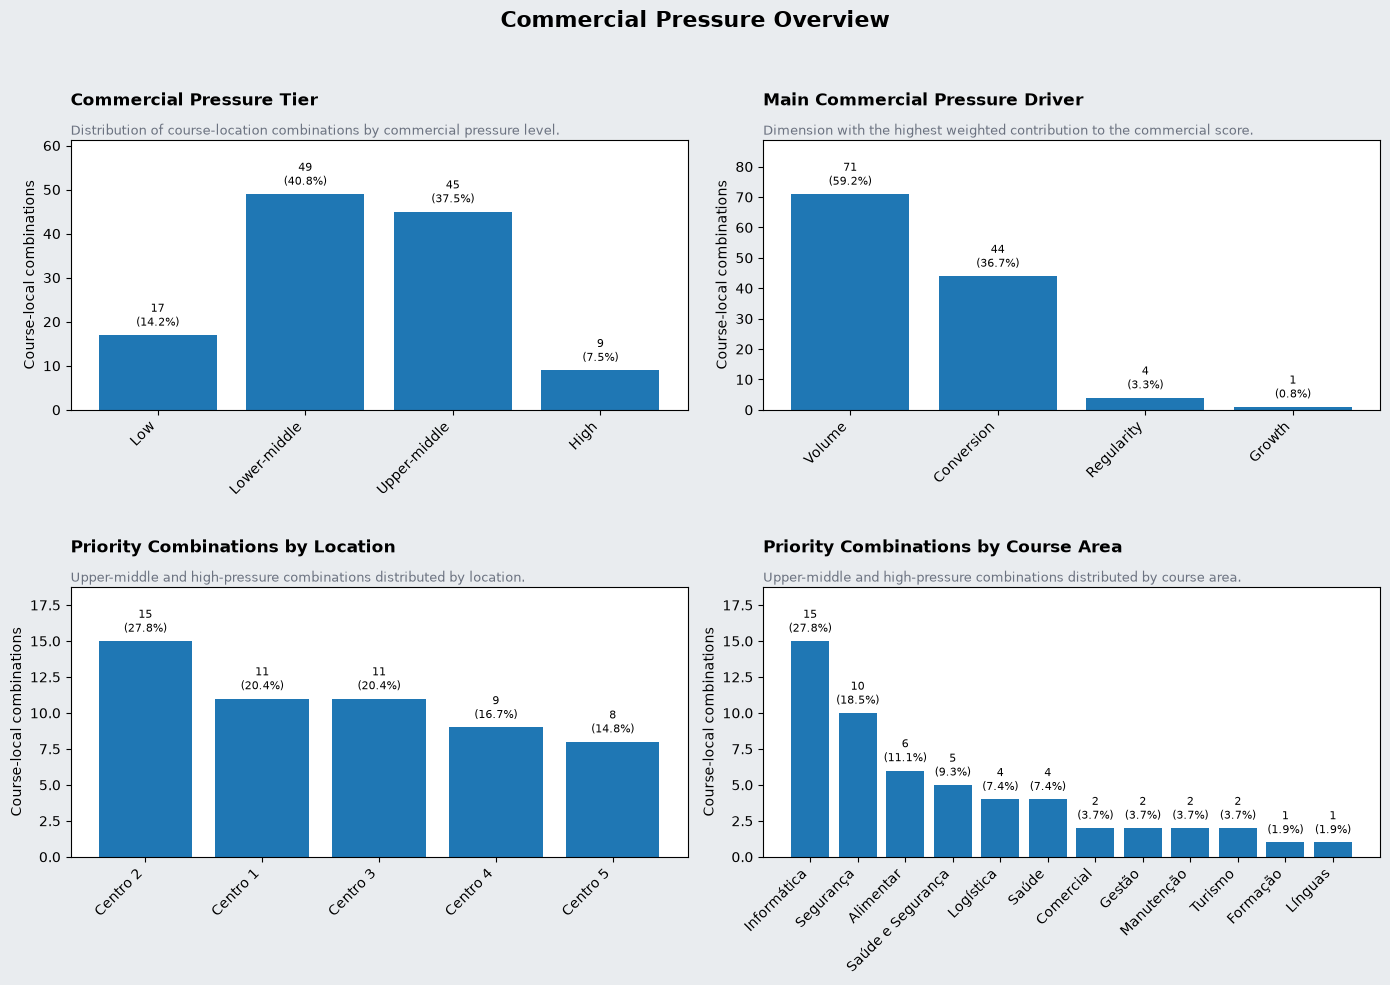

In [69]:
plot_commercial_overview(
    charts=commercial_score_overview_charts,
    title="Commercial Pressure Overview",
    ylabel="Course-local combinations",
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

In [70]:
course_commercial_pressure_charts = {
    "course_pressure": {
        "df": priority_commercial_course_count_df,
        "label_column": "course_id",
        "metric": "score",
        "title": "Courses with the Widest Commercial Pressure",
        "description": (
            "Number of locations where each course belongs to "
            "the upper-middle or high commercial pressure tier."
        )
    }
}

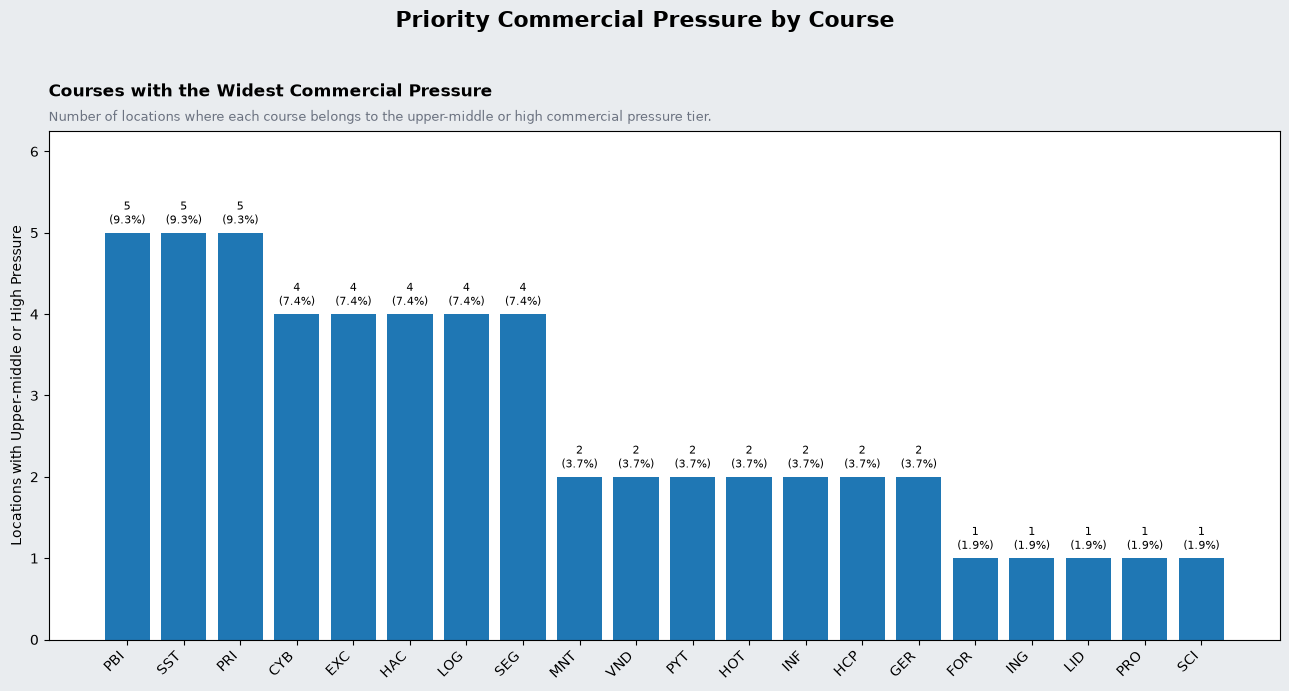

In [71]:
plot_commercial_overview(
    charts=course_commercial_pressure_charts,
    title="Priority Commercial Pressure by Course",
    ylabel="Locations with Upper-middle or High Pressure",
    nrows=1,
    ncols=1,
    figsize=(13, 7)
)

## Key commercial findings

Of the 120 course-location combinations:

- 9 are classified as High pressure;
- 45 are Upper-middle;
- 49 are Lower-middle;
- 17 are Low.

Volume is the main pressure driver for 71 combinations, followed by conversion for 44, regularity for four, and growth for one.

The highest commercial-pressure combinations include:

- Excel Aplicado à Gestão — Centre 4;
- Primeiros Socorros — Centre 1;
- Excel Aplicado à Gestão — Centre 1;
- Power BI e Visualização de Dados — Centre 2;
- Power BI e Visualização de Dados — Centre 4;
- Excel Aplicado à Gestão — Centre 2.

Centre 2 contains the largest number of Upper-middle or High-pressure combinations.

Saúde e Segurança no Trabalho, Power BI e Visualização de Dados, and Primeiros Socorros reach at least Upper-middle pressure in all five locations.

These results identify where market demand creates the greatest commercial pressure. They do not independently establish a recruitment requirement because trainer coverage and observed operational activity must also be considered.

## Export commercial scores

The commercial features, recent and historical dimension scores, weighted contributions, pressure levels, main drivers, and priority ranks are exported to:

`data/scores/commercial_scored_features.csv`

This dataset becomes the commercial-demand input for the final hiring-priority model.

In [72]:
commercial_scored_features_df.to_csv(
    SCORES_DATA_DIR / "commercial_scored_features.csv",
    index=False,
    encoding="utf-8"
)

## Commercial analysis outcome

The commercial analysis transformed lead and sales activity into a structured assessment of volume, conversion, regularity, and growth for all 120 course-location combinations.

The results show that commercial pressure is driven primarily by the scale of lead and sales activity, followed by the effectiveness with which leads are converted into completed sales.

The commercial score will next be combined with workforce vulnerability and operational pressure to determine the overall hiring priority.